# Green--Kubo thermal conductivities of 8NN and 12NN structures
---
As computed by LAMMPS.

## Imports

In [1]:
import numpy as np
import re
import subprocess
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib as mpl
mpl.rcParams["legend.frameon"] = False
mpl.rcParams['figure.dpi']=300 # dots per inch
import scipy as sp
import itertools

## Housekeeping functions

### Extract thermal conductivity
From the logfile -- this is very important, as it forms the backbone of our results!

In [2]:
def extract_TC(file_path):
    """Extracts the thermal conductivity (TC) value from the logfile,
    assuming that the LAMMPS script has already been run.
    Also takes their thermal conductivities
    
    Inputs:
    file_path - path to the logfile we want to read
    
    Outputs:
    thermal_conductivity - thermal conductivity extracted from the logfile (if it is there)
    k_x - thermal conductivity along the x direction extracted from logfile
    k_y - thermal conductivity along the y direction extracted from logfile
    k_z - thermal conductivity along the z direction extracted from logfile
    """
    
    # Open file in Python to read all lines
    with open(file_path, 'r') as file:
        content = file.read()

    # Looks for lines of the form {average conductivity: X[W/mk] @ 70 K, Y /A\^3}
    k_pattern = re.compile(r'average conductivity:\s*([\d.]+)\s*\[W/mK\]', re.IGNORECASE)
    # Search logfile for that line
    k_lines = k_pattern.findall(content)
    
    # If the line exists, extract thermal conductivity. Inform user if otherwise
    if len(k_lines)>0:
        thermal_conductivity = float(k_lines[0])
    else:
        return 'Thermal conductivity not found for this file'
    
    # Look for lines of the form {diretional thermal conductivites: k_x = kx, k_y = ky, k_z = kz}
    ki_pattern = re.compile(
        r'Directional thermal conductivities:\s*'
        r'k_x\s*=\s*(?P<kx>[+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)\s*,\s*'
        r'k_y\s*=\s*(?P<ky>[+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)\s*,\s*'
        r'k_z\s*=\s*(?P<kz>[+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)',
        re.IGNORECASE)
    
    # If the line exists, extract directional conductivity. Inform user if otherwise
    ki_lines = ki_pattern.findall(content)
    if ki_lines:
        kx_str, ky_str, kz_str = ki_lines[0]
        kx = float(kx_str)
        ky = float(ky_str)
        kz = float(kz_str)
    else:
        return 'Directional thermal conductivites not found for this file'
    
    return thermal_conductivity, kx, ky, kz

### Update seeds
Updating seeds is important because of the velocity initialisation process in LAMMPS. Much like many other MD routines, we sample particle velocities from a Gaussian distribution, then scale these velocities up to the desired temperature (if you have done the module PHAS0030 Comp. Phys, there is a similar assignment from 2023/24).

Since these velocities are sampled from a random disribution, we would like to eliminate any potential randomness in our results. For this sake we will update the random velocity initialisation seed, and average our results over these seeds.

In [3]:
def update_seed(file_path, new_seed):
    """Updates the seed for the velocity initialisation command in the LAMMPS input script.
    The velocity in LAMMPS is randomly initialised using a given seed.
    
    Inputs:
    file_path - path to the LAMMPS script which will be updated
    new_seed - new seed to be used in velocity initialisation
    
    Outputs:
    Updated file, if amendments have been made"""
    
    # Looks for lines of the form {variable r equal X}
    pattern = re.compile(r'^\s*variable\s+r\s*equal\s*[\d.]+\s*$')
    
    # Open the file in read mode to read all lines
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Open the file in write mode to update the lines iteratively
    with open(file_path, 'w') as file:
        for line in lines:
            # If the pattern exists, update the line with the new seed in place
            if pattern.match(line):
                line = f"variable r equal {new_seed}\n"
            
            # Write the line to the file
            file.write(line)

### Update masses
I don't think we actually use this in much detail, but essentially updates the masses of the LAMMPS input script.

In [4]:
def update_masses(file_path, new_mass1, new_mass2):
    """Updates the mass1 and mass2 variables in the LAMMPS input script.
    This assumes of course that the LAMMPS script concerns two fundamental atoms.
    
    Inputs:
    file_path - path to the LAMMPS script which will be updated
    new_mass1 - new mass 1 (g/mol)
    new_mass2 - new mass 2 (g/mol)
    
    Outputs:
    Updated file, if any amendments have been made"""
    
    # Looks for lines of the form {mass    1 X} and {mass    2 Y}
    target_pattern_mass1 = re.compile(r'^\s*mass\s+1\s+[\d.]+\s*$')
    target_pattern_mass2 = re.compile(r'^\s*mass\s+2\s+[\d.]+\s*$')
    
    # Open the file in read mode to read all lines
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Open the file in write mode to update the lines iteratively
    with open(file_path, 'w') as file:
        for line in lines:
            # --- Mass 1 ---
            # If the pattern exists, replace mass 1 with new_mass1
            if target_pattern_mass1.match(line):
                line = f"mass 1 {new_mass1}\n"
            # --- Mass 2 ---
            if target_pattern_mass2.match(line):
                line = f"mass 2 {new_mass2}\n"
                
            file.write(line)

### Bash function
Since we will be running many LAMMPS commands, it is nice to automate it - this is exactly what run_bash does below.

In [6]:
def run_bash():
    """Tell Windows to run the lammps.sh file,
    which within it tells LAMMPS to run whichever configuration file is within it."""
    !bash {'lammps.sh'}
    return

### Create LAMMPS compatible datafile
Helper function to generate the structures we are interested in, in LAMMPS compatible datafile format.

In [7]:
def layered_datafile_creation(Ncells, Nlayers, spacings):
    """Creates a datafile of an arbitrary crystallographic material which is LAMMPS compatible.
    Uses the generate_FCC function to generate FCC lattice.
    See the markdown above where this function is defined for details on the datafile structure.
    Alternativiely, view the eim example in LAMMPS.
    
    Inputs:
    
    Output:
    datafile.txt - datafile in LAMMPS format defining the structure"""

    # Find positions, types, IDs and group into data
    positions, atom_types = generate_FCC(Ncells, Nlayers, spacings)
    num_atoms = len(atom_types)
    IDs = np.array(range(1, num_atoms+1))
    data = np.column_stack((IDs, atom_types, positions))

    # Will take the form [ID] [Type] [X1] [Y1] [Z1] column-repeated many times
    np.savetxt('datafile.txt', data, fmt = '%i %i %s %s %s',header = 
f'''# Title

{len(data)} atoms

{len(np.unique(data[:,1]))} atom types

{min(positions[:,0])} {max(positions[:,0]) + 0.5*spacings[0]} xlo xhi
{min(positions[:,1])} {max(positions[:,1]) + 0.5*spacings[1]} ylo yhi
{min(positions[:,2])} {max(positions[:,2]) + 0.5*spacings[2]} zlo zhi

Atoms
''', comments = '')
    
    return

### Generate FCC structure (12NN structure)

In [8]:
def generate_FCC(Ncells, Nlayers, spacings):
    """Creates a face-centered cubic (FCC) structure, according to the TWELVE NEAREST NEIGHBOUR STRUCTURE.
    This specific function assumes two types of atoms.
    
    Inputs:
    Ncells - number of cells as a two-dimensional NumPy vector [Nx, Nz]
    Nlayers - number of layers along y (integer)
    spacings - lattice constant / spacing between cells
    
    Outputs:
    positions - two-dimensional NumPy array of positions [x,y,z] per atom
    atom_types - one-dimensional NumPy array labelling atom types as integers"""
    # Create storage arrays
    positions = []
    atom_types = []

    # Extract spacing and cells
    x_spacing, y_spacing, z_spacing = spacings
    Ncells_x, Ncells_z = Ncells

    # Determine Cartesian range of atoms
    x_range, z_range = range(2*Ncells_x), range(2*Ncells_z) 
    y_range = range(0, 2*Nlayers)

    # Loop over the range of x,y,z
    for x,y,z in itertools.product(x_range, y_range, z_range):
        # First layer: y=0
        if (x%2 == 0 and y%2 == 0 and z%2 == 0):
            x, z = x*0.5*x_spacing, z*0.5*z_spacing
            y = (y//2)*y_spacing
            # Append positions and types
            positions.append([x,y,z])
            atom_types.append(int(1))

        # Second layer: y=1
        elif (x%2 == 0 and y%2 == 1 and z%2 == 1):
            x, z = x*0.5*x_spacing, z*0.5*z_spacing
            y = (y//2 + 0.5)*y_spacing
            # Append positions and types
            positions.append([x,y,z])
            atom_types.append(int(1))

        # First layer again (sorry): y=0
        elif (x%2 == 1 and y%2 == 0 and z%2 == 1):
            x, z = x*0.5*x_spacing, z*0.5*z_spacing
            y = (y//2)*y_spacing
            # Append positions and types
            positions.append([x,y,z])
            atom_types.append(int(1))

        # Second layer: y=1
        elif (x%2 == 1 and y%2 == 1 and z%2 == 0):
            x, z = x*0.5*x_spacing, z*0.5*z_spacing
            y = (y//2 + 0.5)*y_spacing
            # Append positions and types
            positions.append([x,y,z])
            atom_types.append(int(2)) # note that this is type 2 - for 3 type 1's, we have 1 type 2, consistent with the 12NN structure
                                    
    # Convert lists to arrays for plotting & return
    positions = np.array(positions)
    atom_types = np.array(atom_types)
    
    return positions, atom_types

### Update bonds
We don't actually use this particularly often either - its use case was for varying the bonds, but in the end we only use it for epsilon11 = 2*epsilon22. Nevertheless it is a powerful function to have.

In [9]:
def update_bonds(file_path, eps11, eps12, eps22):
    # Target lines in LAMMPS configuration file pertaining to bond types
    # This would be of the form pair_coeff 1 1 epsilon ..., pair_coeff 1 2 epsilon ... , etc
    target_pattern_11 = re.compile(r'^(\s*pair_coeff\s+1\s+1\s+)([^\s#]+)\s+([^\s#]+)(\s*(?:#.*)?)\s*$')
    target_pattern_12 = re.compile(r'^(\s*pair_coeff\s+1\s+2\s+)([^\s#]+)\s+([^\s#]+)(\s*(?:#.*)?)\s*$')
    target_pattern_22 = re.compile(r'^(\s*pair_coeff\s+2\s+2\s+)([^\s#]+)\s+([^\s#]+)(\s*(?:#.*)?)\s*$')

    # Open the file and read its lines in read mode
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Now open the file in write mode to update it
    with open(file_path, 'w') as file:
        # Target lines satisfying pair_coeff * * epsilon sigma
        for line in lines:
            # pair_coeff 1 1 epsilon sigma
            m = target_pattern_11.match(line)
            # If the target matches, update the epsilon part of this line
            if m:
                prefix, _old_eps, old_sig, comment = m.groups()
                file.write(f"{prefix}{eps11} {old_sig}{comment}\n")
                continue

            # pair_coeff 1 1 epsilon sigma
            m = target_pattern_12.match(line)
            if m:
                prefix, _old_eps, old_sig, comment = m.groups()
                file.write(f"{prefix}{eps12} {old_sig}{comment}\n")
                continue

            # pair_coeff 1 1 epsilon sigma
            m = target_pattern_22.match(line)
            if m:
                prefix, _old_eps, old_sig, comment = m.groups()
                file.write(f"{prefix}{eps22} {old_sig}{comment}\n")
                continue

            file.write(line)

### Count amount of nearest neighbour bonds
This function is very important for correct normalisation of thermal conductivities, due to different bonding strengths. The 8NN structure and the 12NN structure will have different bonding strengths within them. Since, by design of the 12NN structure, there are no heavy-heavy bonds. In fact, there are more light-light bonds, which we knowingly made stronger to enhance the effects of rattling.

So below, we count these bounds properly. One could verify that they give the correct results pretty easily, as for a 5x5x5 FCC supercell, we have 500 atoms, with 12 nearest neighbours each (not to be confused with 12NN structure). That then gives 6000 possible nearest neighbour pairs, but 3000 when we do not double count.

Then for the 8NN structure: We note by the structure of the FCC that each face of light atoms will be bonded to 4 light atoms within that same face of the unit cell. As that unit cell is repeated 25 times within a plane parallel to the face of that cell, we expect 100 light-light bonds within that plane. And as we have 10 planes, half of these are light-light, so we expect 500 light-light bonds. Heavy-heavy bonds may be counted similarly to total to 500. Then the remaining 2000 bonds must be between heavy and light atoms. The function below gives this, and was designed for more general use cases, but unfortunately we were limited to just the 8 and 12 NN investigation. 

For the 12NN structure: Owing to the design of the 12NN structure, there should be zero heavy-heavy bonds. The code below counts this. We did not further verify beyond this point, but there's substantial evidence that the function works correctly.

In [10]:
def count_nn_bonds(datafile, lattice_constant):
    """
    Count nearest-neighbour bonds between pairs of types of atoms from a LAMMPS datafile.
    Specifically, the 1-1 bonds, the 1-2 bonds and the 2-2 bonds.

    To do this, we use a cutoff slightly above FCC NN distance ( > a/sqrt(2)) to capture all NN pairs.

    Inputs:
    datafile - LAMMPS datafile we are interested in counting bonds of
    lattice_constant - lattice constant of the system

    Outputs:
    bond_counts - dictionary of bond counts between the three possible pairs
    """
    # Create storage arrays for parsing the datafile
    ids, types, positions = [], [], []
    box_bounds = []

    # Since the LAMMPS datafile may be split into two parts: the header, and the table detailing Atoms
    in_atoms = False
    # Open datafile and read them as lines (we are only reading, not updating anything here)
    with open(datafile, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # These may seem like they are futile, but they are not. We need them to evaluate the
            # dimensions of the box, due to the periodicity of the structure. Example, layer 10 is far away from layer 1
            # but actually, layer 10 and layer 1 are adjacent when periodicity is considered.
            if 'xlo xhi' in line:
                parts = line.split()
                box_bounds.append((float(parts[0]), float(parts[1])))
            elif 'ylo yhi' in line:
                parts = line.split()
                box_bounds.append((float(parts[0]), float(parts[1])))
            elif 'zlo zhi' in line:
                parts = line.split()
                box_bounds.append((float(parts[0]), float(parts[1])))
            # Here's the important part: if we are under the Atoms table, we will count the pairs
            elif line == 'Atoms':
                in_atoms = True
                continue
            # Extract the types, ids and positions of the atoms under this table
            elif in_atoms:
                parts = line.split()
                if len(parts) >= 5:
                    ids.append(int(parts[0]))
                    types.append(int(parts[1]))
                    positions.append([float(parts[2]), float(parts[3]), float(parts[4])])

    # Convert them into NumPy arrays
    types = np.array(types)
    positions = np.array(positions)
    # Also find the length of the box, using the box_bounds earlier
    box_lengths = np.array([hi - lo for lo, hi in box_bounds])

    # Define the nearest neighbour distance, and give it a tolerance (so we capture all NN's)
    nn_distance = lattice_constant / np.sqrt(2)
    cutoff = nn_distance * 1.1  # 10% tolerance -- this is probably a bit high in hindsight!
    
    # Next, we count the bonds and store them into a dictionary
    n_atoms = len(types)
    bond_counts = {'1-1': 0, '1-2': 0, '2-2': 0}

    # Loop over all pairs of atoms (should be 499(499+1)/2 in total for 500 atoms)
    for i in range(n_atoms):
        for j in range(i + 1, n_atoms):
            # Find the difference in positions between the pair of atoms considered
            dr = positions[j] - positions[i]
            # However, also remember that periodicity plays a role.
            dr -= box_lengths * np.round(dr / box_lengths)
            # Convert into scalar distance
            dist = np.linalg.norm(dr)

            # Provided the distance is below the NN cutoff, and is also not tiny enough (so the atoms aren't the same, by chance)
            # We count the types of the pair which pertain to this and add it to bond_counts
            if dist < cutoff and dist > 1e-10:
                t1, t2 = sorted([types[i], types[j]])
                key = f'{t1}-{t2}'
                bond_counts[key] += 1
    
    return bond_counts

### Small test

In [11]:
# Investigate 2x2xn sizes, where n is the amount of layers
Ncells = np.array([5,5])
Nlayers = 5
spacings = np.array([5.376,5.376,5.376])
update_masses("tc.txt", 39.948, 100)

# Extract positions
positions, atom_types = generate_FCC(Ncells, Nlayers, spacings)

# Count amount of occurences of type 1 and 2
atom_types = np.asarray(atom_types)
unique, counts = np.unique(atom_types, return_counts=True)
dict(zip(unique, counts))

{1: 375, 2: 125}

In [12]:
layered_datafile_creation(Ncells, Nlayers, spacings)

## 12 nearest neighbour rattling
Now we find the thermal conductivities using all those functions above for the 12NN case.

**Note the variables written here are the wrong way around, 8 was used to denote 12NN and 12 was used to denote 8NN, my mistake**

In [13]:
# Define epsilon 11 wrt epsilon 22
factor_differences = np.arange(0.5, 2.1, 0.1)
eps11_list = 0.2381*factor_differences

In [14]:
# Loop over increasing layers
layered_datafile_creation(Ncells, Nlayers, spacings)
update_bonds("tc.txt", eps11_list[-1], 0.2381, 0.2381)
seeds = np.random.randint(1,100000,50)
# Thermal conductivites per layer
k_run8, kx_run8, ky_run8, kz_run8 = [], [], [], []
# Loop over seeds
for seed in tqdm(seeds):
    update_seed("tc.txt", seed)
    run_bash()
    # Extract TC and directional TC
    k_seed, kx_seed, ky_seed, kz_seed = extract_TC("log.lammps")
    # Store all seed TC's
    k_run8.append(k_seed)
    kx_run8.append(kx_seed)
    ky_run8.append(ky_seed)
    kz_run8.append(kz_seed)
# Find all TC averages per layer
k_average8 = np.mean(k_run8)
kx_average8 = np.mean(kx_run8)
ky_average8 = np.mean(ky_run8)
kz_average8 = np.mean(kz_run8)
# Also find their errors
k_error8 = (np.std(k_run8, ddof=1) / np.sqrt(len(k_run8)))
kx_error8 = (np.std(kx_run8, ddof=1) / np.sqrt(len(kx_run8)))
ky_error8 = (np.std(ky_run8, ddof=1) / np.sqrt(len(ky_run8)))
kz_error8 = (np.std(kz_run8, ddof=1) / np.sqrt(len(kz_run8)))

100%|███████████████████████████████████████████████████████████████████████████████| 50/50 [3:18:44<00:00, 238.50s/it]


In [15]:
# Find the average bonding strength for this structure
if __name__ == '__main__':
    counts = count_nn_bonds('datafile.txt', lattice_constant=5.376)
avg_epsilon8 = (counts['1-1']*eps11_list[-1] + counts['1-2']*0.2381 + counts['2-2']*0.2381) / (counts['1-1'] + counts['1-2'] + counts['2-2'])

# 8 nearest neighbour rattling

In [16]:
def generate_FCC(Ncells, Nlayers, spacings):
    """Creates a face-centered cubic (FCC) structure. EIGHT NEAREST NEIGHBOUR RATTLING
    
    Inputs:
    Ncells - number of cells as a two-dimensional NumPy vector [Nx, Nz]
    Nlayers - number of layers along y (integer)
    spacings - lattice constant / spacing between cells
    
    Outputs:
    positions - two-dimensional NumPy array of positions [x,y,z] per atom
    type_atoms - one-dimensional NumPy array labelling atom types as integers"""
    # Create storage arrays
    positions = []
    atom_types = []

    # Extract spacing and cells
    x_spacing, y_spacing, z_spacing = spacings
    Ncells_x, Ncells_z = Ncells

    # Determine Cartesian range of atoms
    x_range, z_range = range(2*Ncells_x), range(2*Ncells_z) 
    y_range = range(0, 2*Nlayers)

    # Loop over the range of x,y,z
    for x,y,z in itertools.product(x_range, y_range, z_range):
        # First layer: y=0
        if (x%2 == 0 and y%2 == 0 and z%2 == 0):
            x, z = x*0.5*x_spacing, z*0.5*z_spacing
            y = (y//2)*y_spacing
            # Append positions and types
            positions.append([x,y,z])
            atom_types.append(int(1))

        # Second layer: y=1
        elif (x%2 == 0 and y%2 == 1 and z%2 == 1):
            x, z = x*0.5*x_spacing, z*0.5*z_spacing
            y = (y//2 + 0.5)*y_spacing
            # Append positions and types
            positions.append([x,y,z])
            atom_types.append(int(2)) # we have a new type 2 here in comparison to before

        # First layer again (sorry): y=0
        elif (x%2 == 1 and y%2 == 0 and z%2 == 1):
            x, z = x*0.5*x_spacing, z*0.5*z_spacing
            y = (y//2)*y_spacing
            # Append positions and types
            positions.append([x,y,z])
            atom_types.append(int(1))

        # Second layer: y=1
        elif (x%2 == 1 and y%2 == 1 and z%2 == 0):
            x, z = x*0.5*x_spacing, z*0.5*z_spacing
            y = (y//2 + 0.5)*y_spacing
            # Append positions and types
            positions.append([x,y,z])
            atom_types.append(int(2))
                                    
    # Convert lists to arrays for plotting & return
    positions = np.array(positions)
    atom_types = np.array(atom_types)
    
    return positions, atom_types

In [17]:
# Investigate 2x2xn sizes, where n is the amount of layers
Ncells = np.array([5,5])
Nlayers = 5
spacings = np.array([5.376,5.376,5.376])
update_masses("tc.txt", 39.948, 100)

# Extract positions
positions, atom_types = generate_FCC(Ncells, Nlayers, spacings)

# Count amount of occurences of type 1 and 2
atom_types = np.asarray(atom_types)
unique, counts = np.unique(atom_types, return_counts=True)
dict(zip(unique, counts))

{1: 250, 2: 250}

In [18]:
# Thermal conductivites per layer
layered_datafile_creation(Ncells, Nlayers, spacings)
update_bonds("tc.txt", eps11_list[-1], 0.2381, 0.2381)
k_run12, kx_run12, ky_run12, kz_run12 = [], [], [], []
# Loop over seeds
for seed in tqdm(seeds):
    update_seed("tc.txt", seed)
    run_bash()
    # Extract TC and directional TC
    k_seed, kx_seed, ky_seed, kz_seed = extract_TC("log.lammps")
    # Store all seed TC's
    k_run12.append(k_seed)
    kx_run12.append(kx_seed)
    ky_run12.append(ky_seed)
    kz_run12.append(kz_seed)
# Find all TC averages per layer
k_average12 = np.mean(k_run12)
kx_average12 = np.mean(kx_run12)
ky_average12 = np.mean(ky_run12)
kz_average12 = np.mean(kz_run12)
# Also find their errors
k_error12 = (np.std(k_run12, ddof=1) / np.sqrt(len(k_run12)))
kx_error12 = (np.std(kx_run12, ddof=1) / np.sqrt(len(kx_run12)))
ky_error12 = (np.std(ky_run12, ddof=1) / np.sqrt(len(ky_run12)))
kz_error12 = (np.std(kz_run12, ddof=1) / np.sqrt(len(kz_run12)))

100%|███████████████████████████████████████████████████████████████████████████████| 50/50 [3:19:01<00:00, 238.84s/it]


In [19]:
if __name__ == '__main__':
    counts = count_nn_bonds('datafile.txt', lattice_constant=5.376)
avg_epsilon12 = (counts['1-1']*eps11_list[-1] + counts['1-2']*0.2381 + counts['2-2']*0.2381) / (counts['1-1'] + counts['1-2'] + counts['2-2'])

### I have just realised I wrote my variables the wrong way around!

In [20]:
avg_mass8 = (0.75*39.948 + 0.25*100.0)*np.ones(len(k_run8)) # this is actually the avg mass of 12 NN
avg_mass12 = (0.5*39.948 + 0.5*100.0)*np.ones(len(k_run12)) # this is actually the avg mass of 8 NN
avg_epsilon8 = avg_epsilon8*np.ones(len(k_run8))
avg_epsilon12 = avg_epsilon12*np.ones(len(k_run12))

kx_run8_norm = kx_run8*np.sqrt(avg_mass8/avg_epsilon8)
ky_run8_norm = ky_run8*np.sqrt(avg_mass8/avg_epsilon8)
kz_run8_norm = kz_run8*np.sqrt(avg_mass8/avg_epsilon8)

kx_run12_norm = kx_run12*np.sqrt(avg_mass12/avg_epsilon12)
ky_run12_norm = ky_run12*np.sqrt(avg_mass12/avg_epsilon12)
kz_run12_norm = kz_run12*np.sqrt(avg_mass12/avg_epsilon12)

kx_average8_norm = kx_average8*np.sqrt(avg_mass8[0]/avg_epsilon8[0])
kx_average8_norm_error = kx_error8*np.sqrt(avg_mass8[0]/avg_epsilon8[0])
ky_average8_norm = ky_average8*np.sqrt(avg_mass8[0]/avg_epsilon8[0])
ky_average8_norm_error = ky_error8*np.sqrt(avg_mass8[0]/avg_epsilon8[0])
kz_average8_norm = kz_average8*np.sqrt(avg_mass8[0]/avg_epsilon8[0])
kz_average8_norm_error = kz_error8*np.sqrt(avg_mass8[0]/avg_epsilon8[0])
k_average8_norm = k_average8*np.sqrt(avg_mass8[0]/avg_epsilon8[0])
k_average8_norm_error = k_error8*np.sqrt(avg_mass8[0]/avg_epsilon8[0])


kx_average12_norm = kx_average12*np.sqrt(avg_mass12[0]/avg_epsilon12[0])
kx_average12_norm_error = kx_error12*np.sqrt(avg_mass12[0]/avg_epsilon12[0])
ky_average12_norm = ky_average12*np.sqrt(avg_mass12[0]/avg_epsilon12[0])
ky_average12_norm_error = ky_error12*np.sqrt(avg_mass12[0]/avg_epsilon12[0])
kz_average12_norm = kz_average12*np.sqrt(avg_mass12[0]/avg_epsilon12[0])
kz_average12_norm_error = kz_error12*np.sqrt(avg_mass12[0]/avg_epsilon12[0])
k_average12_norm = k_average12*np.sqrt(avg_mass12[0]/avg_epsilon12[0])
k_average12_norm_error = k_error12*np.sqrt(avg_mass12[0]/avg_epsilon12[0])

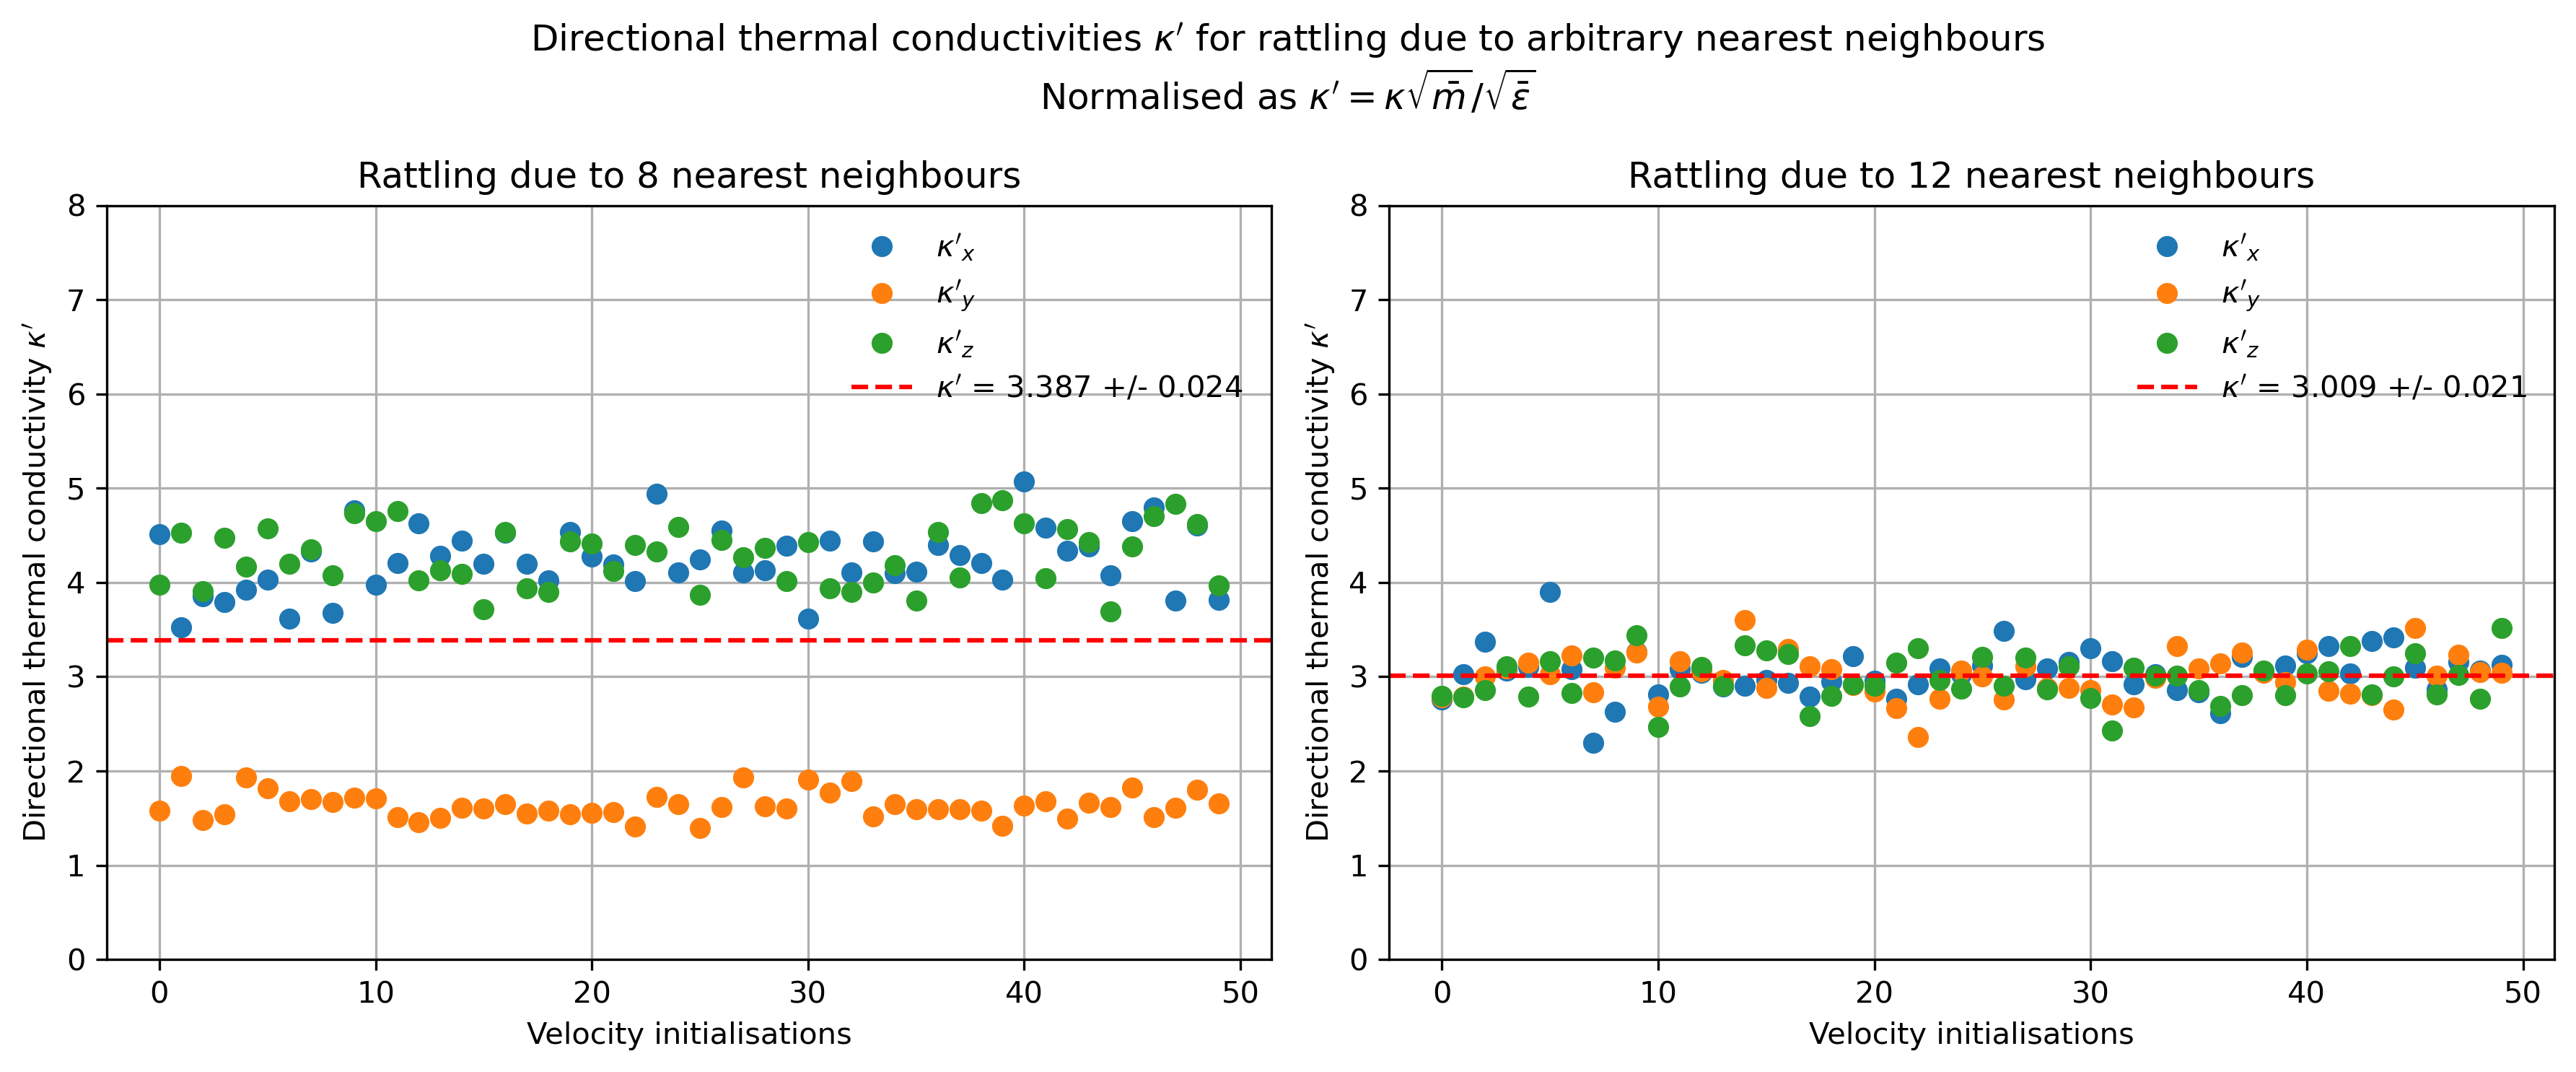

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# Plot directional conductivities
ax2.plot(kx_run8_norm, marker="o", linestyle="None", label=r"$\kappa'_x$")
ax2.plot(ky_run8_norm, marker="o", linestyle="None", label=r"$\kappa'_y$")
ax2.plot(kz_run8_norm, marker="o", linestyle="None", label=r"$\kappa'_z$")
ax2.axhline(k_average8_norm, color="red", linestyle="--", label=f"$\kappa'$ = {k_average8_norm:.3f} +/- {k_average8_norm_error:.3f}")
#ax2.set_xticks(range(len(kx_run8_norm)))
ax2.grid()
ax2.set_xlabel("Velocity initialisations"); ax2.set_ylabel("Directional thermal conductivity $\kappa'$")
ax2.set_title(f"Rattling due to 12 nearest neighbours")
ax2.set_ylim(0, 8)
ax2.legend()

# Plot directional conductivities
ax1.plot(kx_run12_norm, marker="o", linestyle="None", label=r"$\kappa'_x$")
ax1.plot(ky_run12_norm, marker="o", linestyle="None", label=r"$\kappa'_y$")
ax1.plot(kz_run12_norm, marker="o", linestyle="None", label=r"$\kappa'_z$")
ax1.axhline(k_average12_norm, color="red", linestyle="--", label=f"$\kappa'$ = {k_average12_norm:.3f} +/- {k_average12_norm_error:.3f} ")
#ax1.set_xticks(range(len(kx_run12_norm/5)))
ax1.grid()
ax1.set_xlabel("Velocity initialisations"); ax1.set_ylabel("Directional thermal conductivity $\kappa'$")
ax1.set_title(f"Rattling due to 8 nearest neighbours")
ax1.set_ylim(0, 8)
ax1.legend()

plt.suptitle("Directional thermal conductivities $\kappa'$ for rattling due to arbitrary nearest neighbours\n"
          "Normalised as $\\kappa' = \\kappa \\sqrt{\\bar{m}} / \\sqrt{\\bar{\\epsilon}}$")
plt.tight_layout()

In [32]:
print("For 12 nearest neighbour rattling:")
print(f"Isotropically averaged thermal conductivity {k_average8_norm:.3f} with error {k_average8_norm_error:.3f}")
print(f"X averaged thermal conductivity {kx_average8_norm:.3f} with error {kx_average8_norm_error:.3f}")
print(f"Y averaged thermal conductivity {ky_average8_norm:.3f} with error {ky_average8_norm_error:.3f}")
print(f"Z averaged thermal conductivity {kz_average8_norm:.3f} with error {kz_average8_norm_error:.3f}")
print(" ")
print("For 8 nearest neighbour rattling:")
print(f"Isotropically averaged thermal conductivity {k_average12_norm:.3f} with error {k_average12_norm_error:.3f}")
print(f"X averaged thermal conductivity {kx_average12_norm:.3f} with error {kx_average12_norm_error:.3f}")
print(f"Y averaged thermal conductivity {ky_average12_norm:.3f} with error {ky_average12_norm_error:.3f}")
print(f"Z averaged thermal conductivity {kz_average12_norm:.3f} with error {kz_average12_norm_error:.3f}")

For 12 nearest neighbour rattling:
Isotropically averaged thermal conductivity 3.009 with error 0.021
X averaged thermal conductivity 3.049 with error 0.035
Y averaged thermal conductivity 2.992 with error 0.033
Z averaged thermal conductivity 2.986 with error 0.033
 
For 8 nearest neighbour rattling:
Isotropically averaged thermal conductivity 3.387 with error 0.024
X averaged thermal conductivity 4.236 with error 0.048
Y averaged thermal conductivity 1.636 with error 0.019
Z averaged thermal conductivity 4.287 with error 0.045


In [13]:
def generate_FCC(Ncells, Nlayers, spacings):
    """Creates a face-centered cubic (FCC) structure.
    This specific function assumes one type of atom only.
    
    Inputs:
    Ncells - number of cells as a two-dimensional NumPy vector [Nx, Nz]
    Nlayers - number of layers along y (integer)
    spacings - lattice constant / spacing between cells
    
    Outputs:
    positions - two-dimensional NumPy array of positions [x,y,z] per atom
    type_atoms - one-dimensional NumPy array labelling atom types as integers"""
    # Create storage arrays
    positions = []
    atom_types = []

    # Extract spacing and cells
    x_spacing, y_spacing, z_spacing = spacings
    Ncells_x, Ncells_z = Ncells

    # Determine Cartesian range of atoms
    x_range, z_range = range(2*Ncells_x), range(2*Ncells_z) 
    y_range = range(0, 2*Nlayers)

    # Loop over the range of x,y,z
    for x,y,z in itertools.product(x_range, y_range, z_range):
        # First layer: y=0
        if (x%2 == 0 and y%2 == 0 and z%2 == 0):
            x, z = x*0.5*x_spacing, z*0.5*z_spacing
            y = (y//2)*y_spacing
            # Append positions and types
            positions.append([x,y,z])
            atom_types.append(int(1))

        # Second layer: y=1
        elif (x%2 == 0 and y%2 == 1 and z%2 == 1):
            x, z = x*0.5*x_spacing, z*0.5*z_spacing
            y = (y//2 + 0.5)*y_spacing
            # Append positions and types
            positions.append([x,y,z])
            atom_types.append(int(2))

        # First layer again (sorry): y=0
        elif (x%2 == 1 and y%2 == 0 and z%2 == 1):
            x, z = x*0.5*x_spacing, z*0.5*z_spacing
            y = (y//2)*y_spacing
            # Append positions and types
            positions.append([x,y,z])
            atom_types.append(int(1))

        # Second layer: y=1
        elif (x%2 == 1 and y%2 == 1 and z%2 == 0):
            x, z = x*0.5*x_spacing, z*0.5*z_spacing
            y = (y//2 + 0.5)*y_spacing
            # Append positions and types
            positions.append([x,y,z])
            atom_types.append(int(2))
                                    
    # Convert lists to arrays for plotting & return
    positions = np.array(positions)
    atom_types = np.array(atom_types)
    
    return positions, atom_types

In [17]:
factor_differences = np.arange(0.5, 2.1, 0.1)
eps11_list = 0.2381*factor_differences
eps22_list = np.ones(len(eps11_list))*0.2381
eps12_list = eps22_list

In [18]:
if __name__ == '__main__':
    counts = count_nn_bonds('datafile.txt', lattice_constant=5.376)
avg_epsilon8 = (counts['1-1']*eps11_list + counts['1-2']*eps12_list + counts['2-2']*eps22_list) / (counts['1-1'] + counts['1-2'] + counts['2-2'])

In [19]:
avg_epsilon8

array([0.178575, 0.19048 , 0.202385, 0.21429 , 0.226195, 0.2381  ,
       0.250005, 0.26191 , 0.273815, 0.28572 , 0.297625, 0.30953 ,
       0.321435, 0.33334 , 0.345245, 0.35715 ])

In [20]:
# Investigate 2x2xn sizes, where n is the amount of layers
Ncells = np.array([5,5])
Nlayers = 5
spacings = np.array([5.376,5.376,5.376])
update_masses("tc.txt", 39.948, 100)
layered_datafile_creation(Ncells, 5, spacings)

# Setup array storage
k_averages8, k_errors8 = [], []
kx_averages8, kx_errors8 = [], []
ky_averages8, ky_errors8 = [], []
kz_averages8, kz_errors8 = [], []

# Loop over increasing layers
for eps11 in tqdm(eps11_list):
    update_bonds("tc.txt", eps11, 0.2381, 0.2381)
    # Update seeds
    seeds = np.random.randint(1,10000,10)
    # Thermal conductivites per layer
    k_run, kx_run, ky_run, kz_run = [], [], [], []
    # Loop over seeds
    for seed in seeds:
        update_seed("tc.txt", seed)
        run_bash()
        # Extract TC and directional TC
        k_seed, kx_seed, ky_seed, kz_seed = extract_TC("log.lammps")
        # Store all seed TC's
        k_run.append(k_seed)
        kx_run.append(kx_seed)
        ky_run.append(ky_seed)
        kz_run.append(kz_seed)
    # Find all TC averages per layer
    k_averages8.append(np.mean(k_run))
    kx_averages8.append(np.mean(kx_run))
    ky_averages8.append(np.mean(ky_run))
    kz_averages8.append(np.mean(kz_run))
    # Also find their errors
    k_errors8.append(np.std(k_run, ddof=1) / np.sqrt(len(k_run)))
    kx_errors8.append(np.std(kx_run, ddof=1) / np.sqrt(len(kx_run)))
    ky_errors8.append(np.std(ky_run, ddof=1) / np.sqrt(len(ky_run)))
    kz_errors8.append(np.std(kz_run, ddof=1) / np.sqrt(len(kz_run)))

100%|███████████████████████████████████████████████████████████████████████████████| 16/16 [1:49:40<00:00, 411.30s/it]


In [21]:
def generate_FCC(Ncells, Nlayers, spacings):
    """Creates a face-centered cubic (FCC) structure.
    This specific function assumes one type of atom only.
    
    Inputs:
    Ncells - number of cells as a two-dimensional NumPy vector [Nx, Nz]
    Nlayers - number of layers along y (integer)
    spacings - lattice constant / spacing between cells
    
    Outputs:
    positions - two-dimensional NumPy array of positions [x,y,z] per atom
    type_atoms - one-dimensional NumPy array labelling atom types as integers"""
    # Create storage arrays
    positions = []
    atom_types = []

    # Extract spacing and cells
    x_spacing, y_spacing, z_spacing = spacings
    Ncells_x, Ncells_z = Ncells

    # Determine Cartesian range of atoms
    x_range, z_range = range(2*Ncells_x), range(2*Ncells_z) 
    y_range = range(0, 2*Nlayers)

    # Loop over the range of x,y,z
    for x,y,z in itertools.product(x_range, y_range, z_range):
        # First layer: y=0
        if (x%2 == 0 and y%2 == 0 and z%2 == 0):
            x, z = x*0.5*x_spacing, z*0.5*z_spacing
            y = (y//2)*y_spacing
            # Append positions and types
            positions.append([x,y,z])
            atom_types.append(int(1))

        # Second layer: y=1
        elif (x%2 == 0 and y%2 == 1 and z%2 == 1):
            x, z = x*0.5*x_spacing, z*0.5*z_spacing
            y = (y//2 + 0.5)*y_spacing
            # Append positions and types
            positions.append([x,y,z])
            atom_types.append(int(1))

        # First layer again (sorry): y=0
        elif (x%2 == 1 and y%2 == 0 and z%2 == 1):
            x, z = x*0.5*x_spacing, z*0.5*z_spacing
            y = (y//2)*y_spacing
            # Append positions and types
            positions.append([x,y,z])
            atom_types.append(int(1))

        # Second layer: y=1
        elif (x%2 == 1 and y%2 == 1 and z%2 == 0):
            x, z = x*0.5*x_spacing, z*0.5*z_spacing
            y = (y//2 + 0.5)*y_spacing
            # Append positions and types
            positions.append([x,y,z])
            atom_types.append(int(2))
                                    
    # Convert lists to arrays for plotting & return
    positions = np.array(positions)
    atom_types = np.array(atom_types)
    
    return positions, atom_types

In [22]:
factor_differences = np.arange(0.5, 2.1, 0.1)
eps11_list = 0.2381*factor_differences
eps22_list = np.ones(len(eps11_list))*0.2381
eps12_list = eps22_list

In [23]:
if __name__ == '__main__':
    counts = count_nn_bonds('datafile.txt', lattice_constant=5.376)
avg_epsilon12 = (counts['1-1']*eps11_list + counts['1-2']*eps12_list + counts['2-2']*eps22_list) / (counts['1-1'] + counts['1-2'] + counts['2-2'])

In [24]:
# Investigate 2x2xn sizes, where n is the amount of layers
Ncells = np.array([5,5])
Nlayers = 5
spacings = np.array([5.376,5.376,5.376])
update_masses("tc.txt", 39.948, 100)
layered_datafile_creation(Ncells, 5, spacings)

# Setup array storage
k_averages12, k_errors12 = [], []
kx_averages12, kx_errors12 = [], []
ky_averages12, ky_errors12 = [], []
kz_averages12, kz_errors12 = [], []

# Loop over increasing layers
for eps11 in tqdm(eps11_list):
    update_bonds("tc.txt", eps11, 0.2381, 0.2381)
    # Update seeds
    seeds = np.random.randint(1,10000,10)
    # Thermal conductivites per layer
    k_run, kx_run, ky_run, kz_run = [], [], [], []
    # Loop over seeds
    for seed in seeds:
        update_seed("tc.txt", seed)
        run_bash()
        # Extract TC and directional TC
        k_seed, kx_seed, ky_seed, kz_seed = extract_TC("log.lammps")
        # Store all seed TC's
        k_run.append(k_seed)
        kx_run.append(kx_seed)
        ky_run.append(ky_seed)
        kz_run.append(kz_seed)
    # Find all TC averages per layer
    k_averages12.append(np.mean(k_run))
    kx_averages12.append(np.mean(kx_run))
    ky_averages12.append(np.mean(ky_run))
    kz_averages12.append(np.mean(kz_run))
    # Also find their errors
    k_errors12.append(np.std(k_run, ddof=1) / np.sqrt(len(k_run)))
    kx_errors12.append(np.std(kx_run, ddof=1) / np.sqrt(len(kx_run)))
    ky_errors12.append(np.std(ky_run, ddof=1) / np.sqrt(len(ky_run)))
    kz_errors12.append(np.std(kz_run, ddof=1) / np.sqrt(len(kz_run)))

100%|███████████████████████████████████████████████████████████████████████████████| 16/16 [1:47:50<00:00, 404.38s/it]


In [25]:
avg_mass12 = (0.75*39.948 + 0.25*100.0)*np.ones(len(k_averages12)) # this is actually the avg mass of 12 NN
avg_mass8 = (0.5*39.948 + 0.5*100.0)*np.ones(len(k_averages8)) # this is actually the avg mass of 8 NN

k_averages8_norm = k_averages8*np.sqrt(avg_mass8/avg_epsilon8)
kx_averages8_norm = kx_averages8*np.sqrt(avg_mass8/avg_epsilon8)
ky_averages8_norm = ky_averages8*np.sqrt(avg_mass8/avg_epsilon8)
kz_averages8_norm = kz_averages8*np.sqrt(avg_mass8/avg_epsilon8)

k_errors8_norm = k_errors8*np.sqrt(avg_mass8/avg_epsilon8)
kx_errors8_norm = kx_errors8*np.sqrt(avg_mass8/avg_epsilon8)
ky_errors8_norm = ky_errors8*np.sqrt(avg_mass8/avg_epsilon8)
kz_errors8_norm = kz_errors8*np.sqrt(avg_mass8/avg_epsilon8)

k_averages12_norm = k_averages12*np.sqrt(avg_mass12/avg_epsilon12)
kx_averages12_norm = kx_averages12*np.sqrt(avg_mass12/avg_epsilon12)
ky_averages12_norm = ky_averages12*np.sqrt(avg_mass12/avg_epsilon12)
kz_averages12_norm = kz_averages12*np.sqrt(avg_mass12/avg_epsilon12)

k_errors12_norm = k_errors12*np.sqrt(avg_mass12/avg_epsilon12)
kx_errors12_norm = kx_errors12*np.sqrt(avg_mass12/avg_epsilon12)
ky_errors12_norm = ky_errors12*np.sqrt(avg_mass12/avg_epsilon12)
kz_errors12_norm = kz_errors12*np.sqrt(avg_mass12/avg_epsilon12)

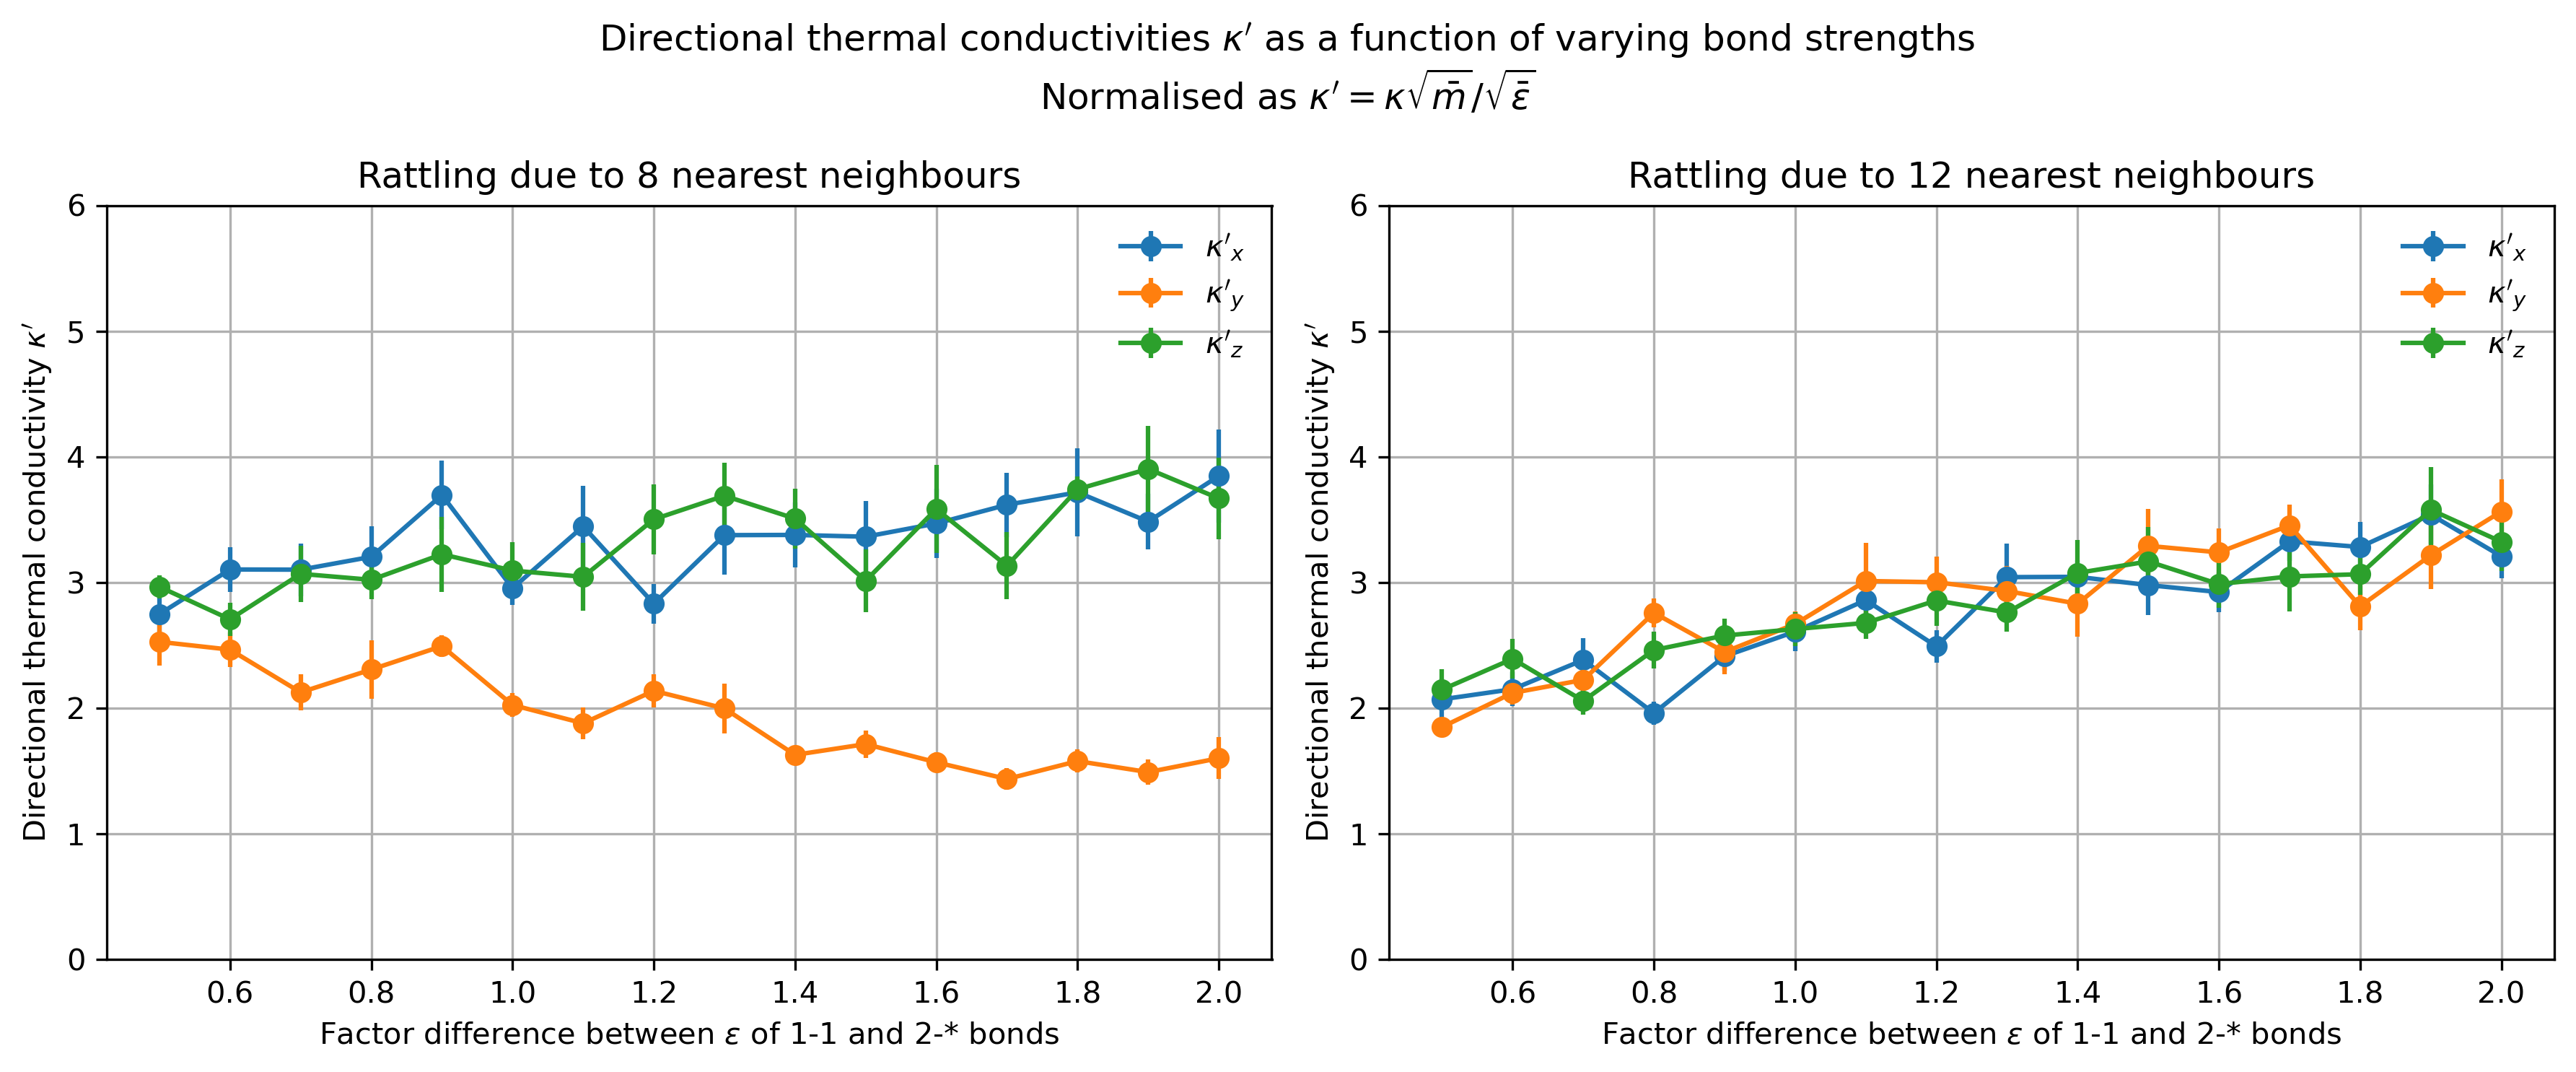

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot directional conductivities
ax1.errorbar(factor_differences, kx_averages8_norm, yerr=kx_errors8_norm, fmt='o-', label=r"$\kappa'_x$")
ax1.errorbar(factor_differences, ky_averages8_norm, yerr=ky_errors8_norm, fmt='o-', label=r"$\kappa'_y$")
ax1.errorbar(factor_differences, kz_averages8_norm, yerr=kz_errors8_norm, fmt='o-', label=r"$\kappa'_z$")
#ax1.errorbar(factor_differences, k_averages8_norm, yerr=k_errors8_norm, fmt='--', label=r"$\kappa'$")
ax1.grid()
ax1.set_xlabel("Factor difference between $\epsilon$ of 1-1 and 2-* bonds"); ax1.set_ylabel("Directional thermal conductivity $\kappa'$")
ax1.set_title("Rattling due to 8 nearest neighbours")
ax1.legend()
ax1.set_ylim(0, 6)

# Plot average conductivities
ax2.errorbar(factor_differences, kx_averages12_norm, yerr=kx_errors12_norm, fmt='o-', label=r"$\kappa'_x$")
ax2.errorbar(factor_differences, ky_averages12_norm, yerr=ky_errors12_norm, fmt='o-', label=r"$\kappa'_y$")
ax2.errorbar(factor_differences, kz_averages12_norm, yerr=kz_errors12_norm, fmt='o-', label=r"$\kappa'_z$")
#ax2.errorbar(factor_differences, k_averages12_norm, yerr=k_errors12_norm, fmt='--', label=r"$\kappa'$")
ax2.grid()
ax2.set_xlabel("Factor difference between $\epsilon$ of 1-1 and 2-* bonds"); ax2.set_ylabel("Directional thermal conductivity $\kappa'$")
ax2.set_title("Rattling due to 12 nearest neighbours")
ax2.legend()
ax2.set_ylim(0, 6)

plt.suptitle("Directional thermal conductivities $\kappa'$ as a function of varying bond strengths \n"
          "Normalised as $\\kappa' = \\kappa \\sqrt{\\bar{m}} / \\sqrt{\\bar{\\epsilon}}$")
plt.tight_layout()

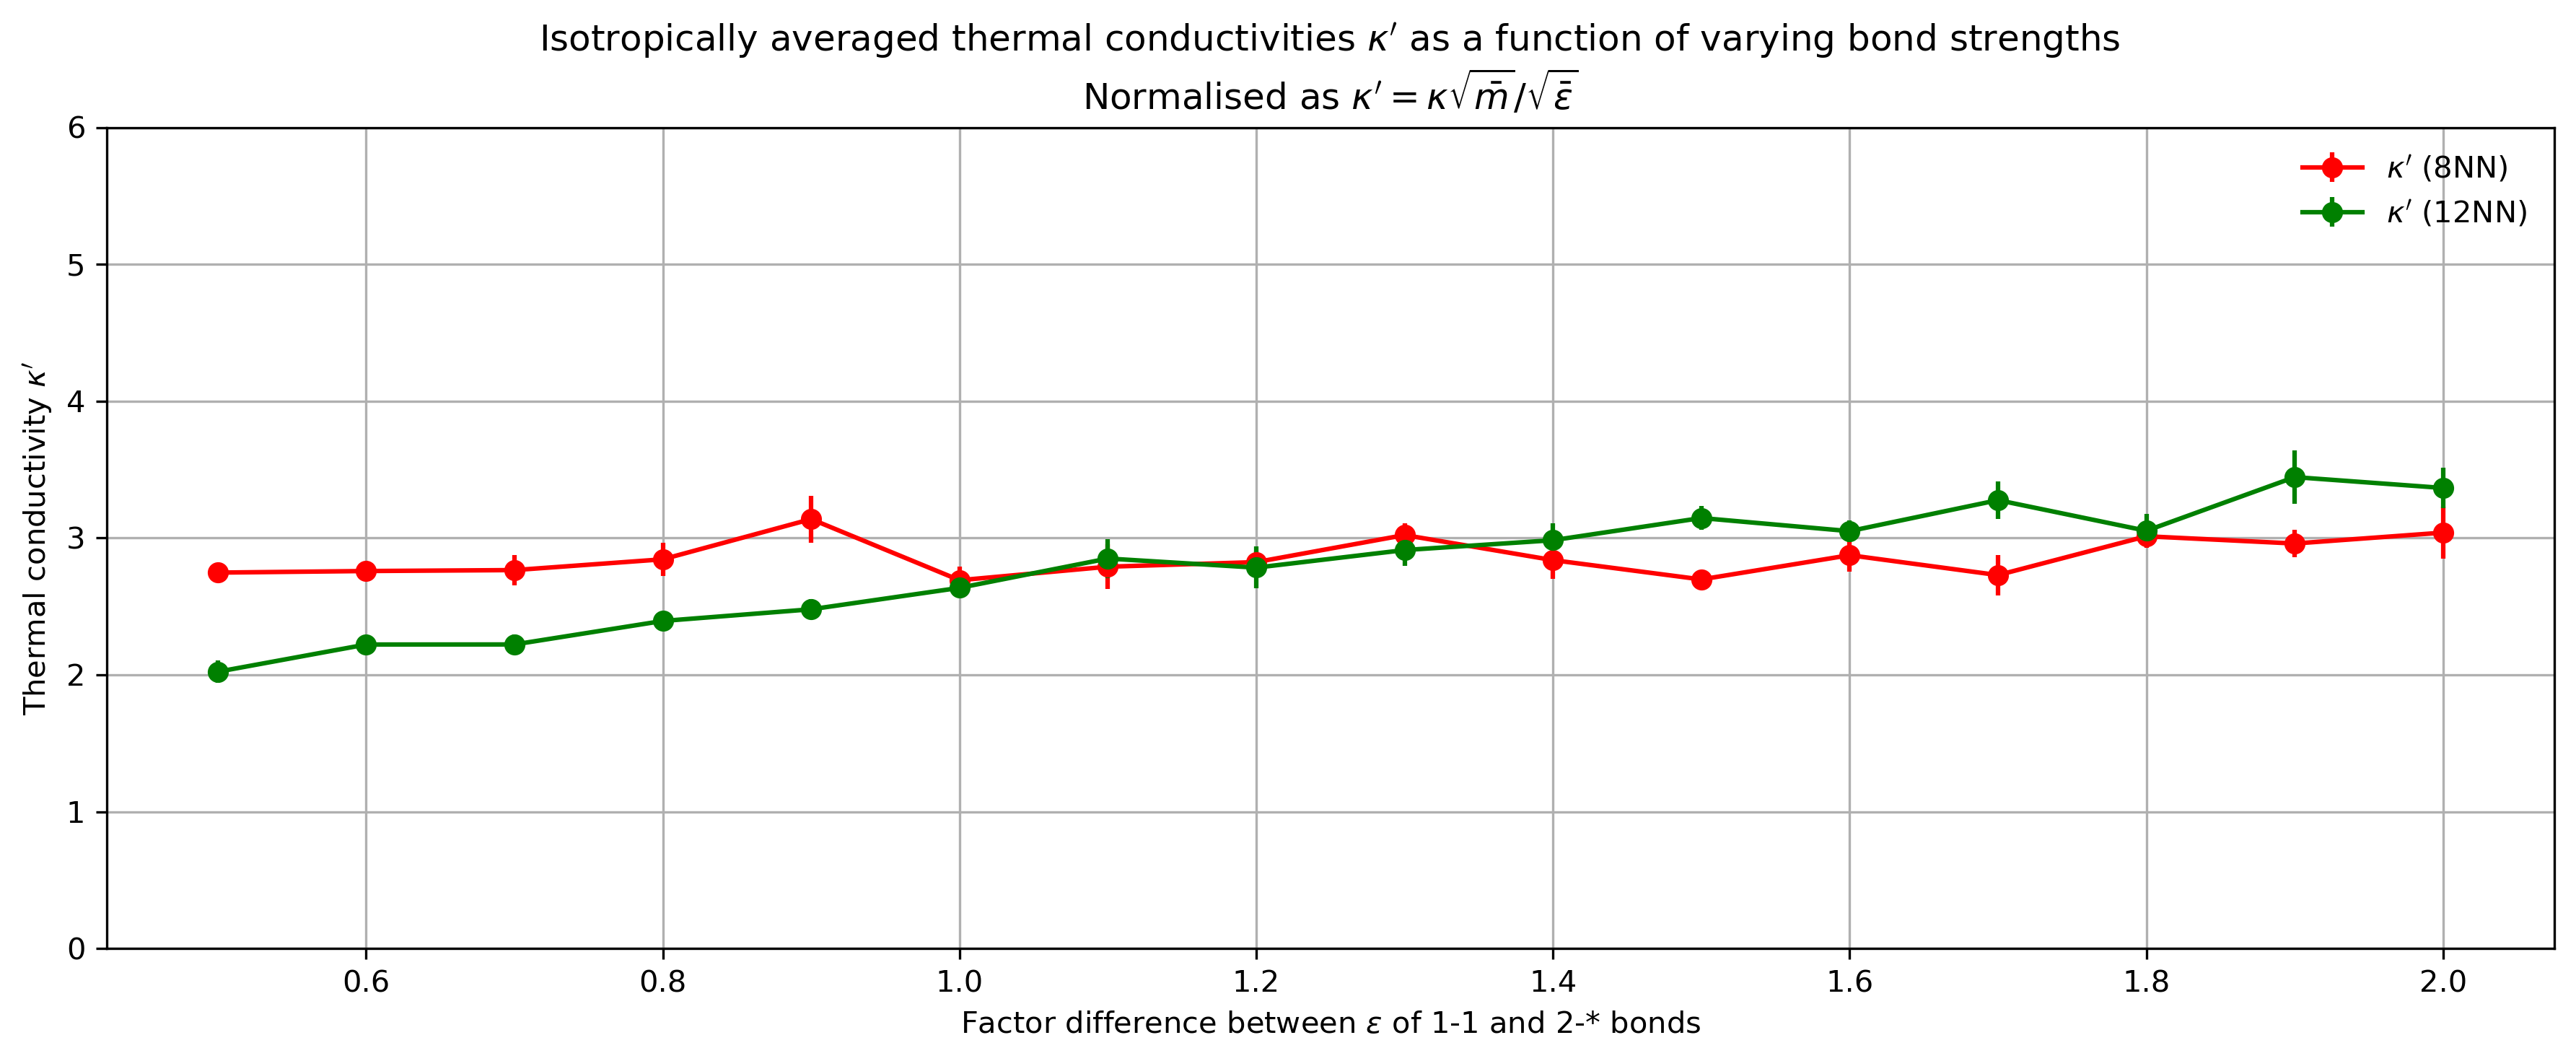

In [38]:
fig, ax1 = plt.subplots(1, 1, figsize=(12, 5))

# Plot directional conductivities
ax1.errorbar(factor_differences, k_averages8_norm, yerr=k_errors8_norm, fmt='o-', label=r"$\kappa'$ (8NN)",color='red')
ax1.errorbar(factor_differences, k_averages12_norm, yerr=k_errors12_norm, fmt='o-', label=r"$\kappa'$ (12NN)",color='green')
ax1.grid()
ax1.set_xlabel("Factor difference between $\epsilon$ of 1-1 and 2-* bonds"); ax1.set_ylabel("Thermal conductivity $\kappa'$")
ax1.set_title("Isotropically averaged thermal conductivities $\kappa'$ as a function of varying bond strengths \n"
          "Normalised as $\\kappa' = \\kappa \\sqrt{\\bar{m}} / \\sqrt{\\bar{\\epsilon}}$")
ax1.legend()
ax1.set_ylim(0, 6)

plt.tight_layout()